In [1]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FormatStrFormatter as fsf
from plots.mpltoolkit import mpl_loc, fancy_legend, named_colors, load_style_sheet, negative_log
import numpy as np
import vice
import sys
import os
sys.path.insert(0, "..")
from src.utils import subsample_stars, get_velocity_evolution, get_velocity_profile
load_style_sheet("papers")
print(sys.version_info[:])

/Users/jamesjohnson/Work/Research/lib/public-dev/VICE/vice/version.py:137: VersionWarning: Using an un-released version of VICE.
  if not self.isreleased: warnings.warn("""\


(3, 12, 3, 'final', 0)


In [2]:
# output = vice.output("../outputs/expifr/base")
output = vice.output("../outputs/expifr-GSE/initial")
# output = vice.output("../outputs/expifr-GSE/initial2")
extra = np.genfromtxt("%s_analogdata.out" % (output.name))
output.stars["absz"] = [abs(_) for _ in extra[:,-1][:output.stars.size[0]]]

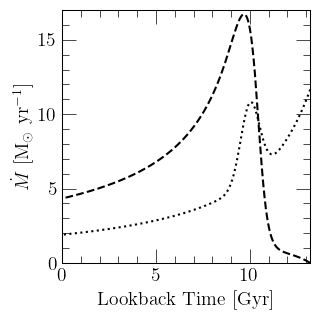

In [14]:
fig = plt.figure(figsize = (3.3, 3.3))
ax = fig.add_subplot(111)
ax.set_xlabel(r"Lookback Time [Gyr]")
ax.set_ylabel(r"$\dot{M}$ [M$_\odot$ yr$^{-1}$]")
ax.set_xlim([0, 13.2])
ax.set_ylim([0, 17])

def plot_ifr_sfr(ax, output, **kwargs):
    lookback = output.zones["zone0"].history["lookback"]
    ifr = len(lookback) * [0.]
    sfr = len(lookback) * [0.]
    for i in range(len(lookback)):
        ifr[i] += sum([output.zones["zone%d" % (_)].history["ifr"][i] for _ in range(len(output.zones.keys()))])
        sfr[i] += sum([output.zones["zone%d" % (_)].history["sfr"][i] for _ in range(len(output.zones.keys()))])
    ifr = []
    sfr = []
    for i in range(len(lookback)):
        ifr.append(0)
        sfr.append(0)
        for j in range(len(output.zones.keys())):
            ifr[-1] += output.zones["zone%d" % (j)].history["ifr"][i]
            sfr[-1] += output.zones["zone%d" % (j)].history["sfr"][i]
    ax.plot(lookback, ifr, linestyle = ":", **kwargs)
    ax.plot(lookback, sfr, linestyle = "--", **kwargs)

plot_ifr_sfr(ax, output, c = named_colors()["black"])

plt.tight_layout()
plt.show()

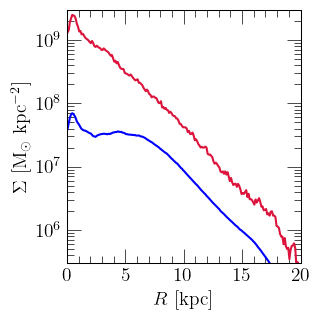

In [15]:
fig = plt.figure(figsize = (3.3, 3.3))
ax = fig.add_subplot(111)
ax.set_xlabel(r"$R$ [kpc]")
ax.set_ylabel(r"$\Sigma$ [M$_\odot$ kpc$^{-2}$]")
ax.set_xlim([0, 20])
ax.set_ylim([3e5, 3e9])
ax.set_yscale("log")

def plot_density_profile(ax, output, which = "stars", zone_width = 0.1, **kwargs):
    radii = [zone_width * (i + 0.5) for i in range(len(output.zones.keys()))]
    sigma = []
    for i in range(len(radii)):
        area = np.pi * zone_width**2 * ((i + 1)**2 - i**2)
        match which:
            case "stars":
                stars = output.stars.filter("zone_final", "==", i)
                sigma.append(sum(stars["mass"]) / area)
            case "gas":
                sigma.append(output.zones["zone%d" % (i)].history["mgas"][-1] / area)
            case _:
                raise ValueError("Bad 'which': %s. Should be 'stars' or 'gas.'" % (which))
    ax.plot(radii, sigma, **kwargs)

plot_density_profile(ax, output, which = "stars", c = named_colors()["crimson"])
plot_density_profile(ax, output, which = "gas", c = named_colors()["blue"])

plt.tight_layout()
plt.show()

/Users/jamesjohnson/Work/Research/lib/personal/plots/mpltoolkit/core.py:96: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(labels)


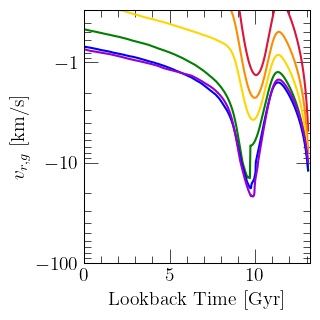

In [16]:
RADII = [3, 5, 7, 9, 11, 13]
COLORS = ["crimson", "darkorange", "gold", "green", "blue", "darkviolet"]

fig = plt.figure(figsize = (3.3, 3.3))
ax = fig.add_subplot(111)
ax.set_xlabel(r"Lookback Time [Gyr]")
ax.set_ylabel(r"$v_{r,g}$ [km/s]")
ax.set_xlim([0, 13.2])
ax.set_ylim([0.3, 100])
ax.set_yscale("log")
ax.yaxis.set_major_formatter(fsf("%g"))

def plot_velocity_evolution(ax, output, radius = 8, zone_width = 0.1, **kwargs):
    lookback, vgas = get_velocity_evolution(output, radius = radius, zone_width = zone_width)
    vgas = [-v for v in vgas]
    ax.plot(lookback, vgas, **kwargs)

for i in range(len(RADII)):
    kwargs = {
        "c": named_colors()[COLORS[i]],
        "label": r"$R = %d$ kpc" % (RADII[i])
    }
    plot_velocity_evolution(ax, output, radius = RADII[i], **kwargs)

negative_log(ax)
plt.tight_layout()
plt.show()

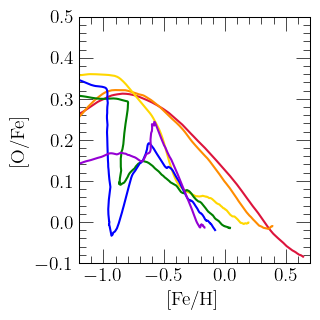

In [17]:
RADII = [3, 5, 7, 9, 11, 13]
COLORS = ["crimson", "darkorange", "gold", "green", "blue", "darkviolet"]

fig = plt.figure(figsize = (3.3, 3.3))
ax = fig.add_subplot(111)
ax.set_xlabel(r"[Fe/H]")
ax.set_ylabel(r"[O/Fe]")
ax.set_xlim([-1.2, 0.7])
ax.set_xticks([-1, -0.5, 0, 0.5])
ax.set_ylim([-0.1, 0.5])

def plot_track(ax, output, radius = 8, zone_width = 0.1, **kwargs):
    zone = int(radius / zone_width)
    zone = output.zones["zone%d" % (zone)]
    ax.plot(zone.history["[fe/h]"], zone.history["[o/fe]"], **kwargs)

for i in range(len(RADII)):
    kwargs = {
        "c": named_colors()[COLORS[i]],
        "label": r"$R = %d$ kpc" % (RADII[i])
    }
    plot_track(ax, output, radius = RADII[i], **kwargs)

plt.tight_layout()
plt.show()

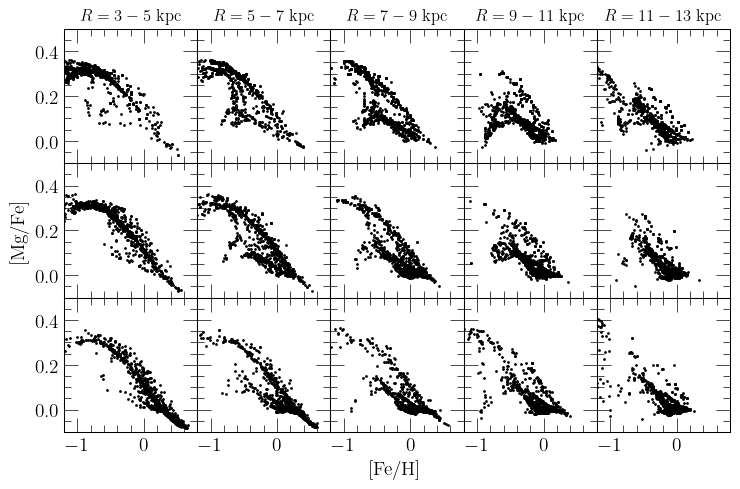

In [18]:
RADII = [[3, 5], [5, 7], [7, 9], [9, 11], [11, 13]]
ZHEIGHTS = [[1, 2], [0.5, 1], [0, 0.5]]
XLIM = [-1.2, 0.8]
YLIM = [-0.1, 0.5]
XTICKS = [-1, 0]
YTICKS = [0, 0.2, 0.4]

fig, axes = plt.subplots(nrows = len(ZHEIGHTS), ncols = len(RADII), sharex = True, sharey = True, figsize = (7.5, 5))
axes[len(ZHEIGHTS) // 2][0].set_ylabel(r"[Mg/Fe]")
axes[-1][len(RADII) // 2].set_xlabel(r"[Fe/H]")
axes[0][0].set_xlim(XLIM)
axes[0][0].set_ylim(YLIM)
axes[0][0].set_xticks(XTICKS)
axes[0][0].set_yticks(YTICKS)
for i in range(len(axes)):
    for j in range(len(axes[i])):
        if j: plt.setp(axes[i][j].get_yticklabels(), visible = False)
        if i != len(axes) - 1: plt.setp(axes[i][j].get_xticklabels(), visible = False)
        if not i: axes[i][j].set_title(r"$R = %d - %d$ kpc" % (RADII[j][0], RADII[j][1]), fontsize = 12)

def plot_subset(ax, output, rmin = 7, rmax = 9, abszmin = 0, abszmax = 0.5, zone_width = 0.1, n = 1000, **kwargs):
    zone_min = int(rmin / zone_width)
    zone_max = int(rmax / zone_width) - 1
    stars = output.stars.filter(
        "zone_final", ">=", zone_min).filter(
        "zone_final", "<=", zone_max).filter(
        "absz", ">=", abszmin).filter(
        "absz", "<=", abszmax).filter(
        "mass", ">", 1)
    stars = subsample_stars(stars, n = n)
    ax.scatter(stars["[fe/h]"], stars["[o/fe]"], **kwargs)

for i in range(len(ZHEIGHTS)):
    for j in range(len(RADII)):
        kwargs = {
            "c": named_colors()["black"],
            "s": 1,
            "rasterized": True,
        }
        plot_subset(axes[i][j], output,
            rmin = RADII[j][0], rmax = RADII[j][1],
            abszmin = ZHEIGHTS[i][0], abszmax = ZHEIGHTS[i][1],
            **kwargs)

plt.tight_layout()
plt.subplots_adjust(hspace = 0, wspace = 0)
plt.show()

KeyError: 'Unrecognized dataframe key: [y/h]'

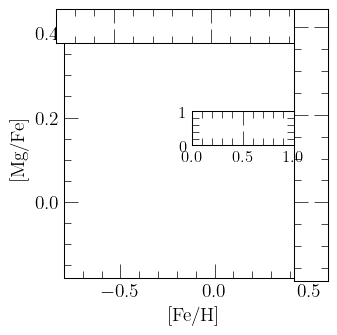

In [4]:
RMIN = 7
RMAX = 9
ABSZMIN = 0
ABSZMAX = 0.5
NSTARS = 10000
AGE_BINS = [[0, 2], [4, 6], [8, 10]]
COLORMAP = "viridis"
# CMAP = plt.get_cmap("viridis")

fig = plt.figure(figsize = (3.4, 3.4))
ax = fig.add_subplot(111)
ax.set_xlabel(r"[Fe/H]")
ax.set_ylabel(r"[Mg/Fe]")
ax.set_xlim([-0.8, 0.6])
ax.set_ylim([-0.18, 0.44])
top = fig.add_axes([0.1, 0.8, 0.8, 0.1], sharex = ax)
right = fig.add_axes([0.8, 0.1, 0.1, 0.8], sharey = ax)
top.tick_params(axis = 'y', which = "both", left = False, right = False)
right.tick_params(axis = 'x', which = "both", top = False, bottom = False)
for ax_ in [top, right]:
    plt.setp(ax_.get_xticklabels(), visible = False)
    plt.setp(ax_.get_yticklabels(), visible = False)

norm = plt.Normalize(vmin = 0, vmax = 10)
# sm = plt.cm.ScalarMappable(cmap = COLORMAP, norm = norm)
cmap = plt.get_cmap(COLORMAP)
cbar_ax = fig.add_axes([0.5, 0.5, 0.3, 0.1])
cbar_ax.tick_params(labelsize = 12)

def plot_stars(ax, top, right, output, zone_width = 0.1, n = 1000, **kwargs):
    stars = output.stars.filter(
        "zone_final", ">=", int(RMIN / zone_width)).filter(
        "zone_final", "<=", int(RMAX / zone_width) - 1).filter(
        "absz", ">=", ABSZMIN).filter(
        "absz", "<=", ABSZMAX)
    sub = subsample_stars(stars, n = n)
    feh = sub["[fe/h]"]
    ofe = sub["[o/fe]"]
    age = sub["age"]
    for i in range(len(feh)):
        feh[i] += np.random.normal(loc = 0, scale = 0.01)
        ofe[i] += np.random.normal(loc = 0, scale = 0.017)
        age[i] = 10**(np.log10(age[i]) + np.random.normal(loc = 0, scale = 0.1))
    sm = ax.scatter(sub["[fe/h]"], sub["[o/fe]"], c = age, **kwargs)
    for i in range(len(AGE_BINS)):
        sub = stars.filter(
            "age", ">=", AGE_BINS[i][0]).filter(
            "age", "<=", AGE_BINS[i][1])
        hist_kwargs = {
            "bins": 50,
            "density": True,
            "weights": sub["mass"]
        }
        step_kwargs = {
            "where": "post",
            "c": cmap(norm(sum(AGE_BINS[i]) / 2))
        }
        counts, bins = np.histogram(sub["[fe/h]"], range = ax.get_xlim(), **hist_kwargs)
        top.step(bins[:-1], counts, **step_kwargs)
        counts, bins = np.histogram(sub["[o/fe]"], range = ax.get_ylim(), **hist_kwargs)
        right.step(counts, bins[:-1], **step_kwargs)
    return sm

sm = plot_stars(ax, top, right, output, n = 10000, vmin = 0, vmax = 10, s = 0.1, rasterized = True)
cbar = plt.colorbar(sm, cax = cbar_ax, orientation = "horizontal")
cbar.set_label(r"Age [Gyr]", fontsize = 12)

top.set_ylim([0, top.get_ylim()[1]])
right.set_xlim([0, right.get_xlim()[1]])

plt.tight_layout()
plt.subplots_adjust(right = 0.78, top = 0.78)
cbar_ax.set_position([
    0.55 * (ax.get_position().x1 - ax.get_position().x0) + ax.get_position().x0,
    0.85 * (ax.get_position().y1 - ax.get_position().y0) + ax.get_position().y0,
    0.35 * (ax.get_position().x1 - ax.get_position().x0),
    0.05
])
top.set_position([
    ax.get_position().x0,
    ax.get_position().y1,
    ax.get_position().x1 - ax.get_position().x0,
    0.2
])
right.set_position([
    ax.get_position().x1,
    ax.get_position().y0,
    0.2,
    ax.get_position().y1 - ax.get_position().y0
])
plt.show()